<a href="https://colab.research.google.com/github/vinicuervo/Calculo-Numerico/blob/main/atividade_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Atividade 1 - Cálculo Numérico

Mariana Froes Grimaldi - 187574

Vinicius Cruz Cuervo - 185337

##Parte 01 a 03.

Feito por Mariana

=== TABELA DE RESULTADOS ===
Variável  Valor referência  n  Valor truncado   Ea_Trunc   Er_Trunc     E%_Trunc  Valor arredondado   Ea_Arred   Er_Arred     E%_Arred
      x1        3.14159265  0      3.00000000 0.14159265 0.04507034   4.50703404         3.00000000 0.14159265 0.04507034   4.50703404
      x1        3.14159265  1      3.10000000 0.04159265 0.01323935   1.32393517         3.10000000 0.04159265 0.01323935   1.32393517
      x1        3.14159265  2      3.14000000 0.00159265 0.00050696   0.05069562         3.14000000 0.00159265 0.00050696   0.05069562
      x1        3.14159265  3      3.14100000 0.00059265 0.00018865   0.01886464         3.14200000 0.00040735 0.00012966   0.01296635
      x1        3.14159265  4      3.14150000 0.00009265 0.00002949   0.00294914         3.14160000 0.00000735 0.00000234   0.00023396
      x2       98.76543000  0     98.00000000 0.76543000 0.00774998   0.77499789        99.00000000 0.23457000 0.00237502   0.23750213
      x2       98.76543000

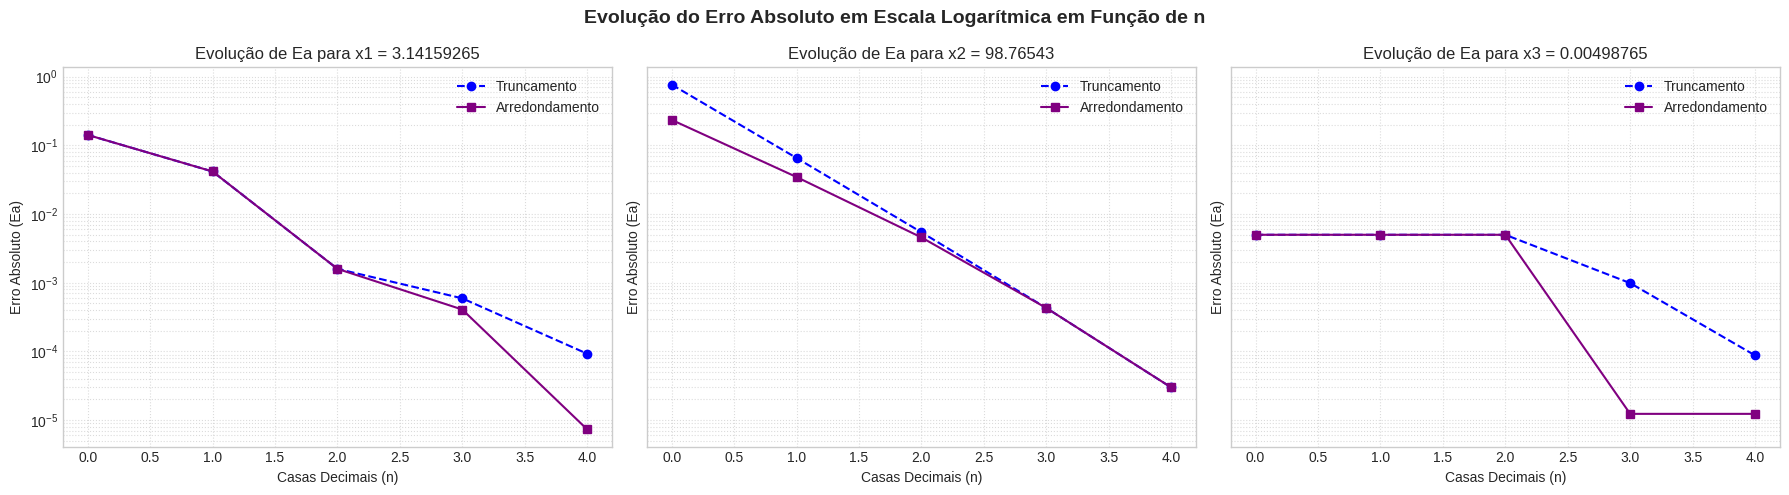

In [9]:
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Define um estilo visual para todos os gráficos do notebook.
plt.style.use("seaborn-v0_8-whitegrid")

# Função de truncamento
def truncar(numero, casas):
    fator = 10**casas
    return math.trunc(numero * fator) / fator

# Função de cálculo de erros
def calcular_erros(x_ref, x_aprox):
    ea = abs(x_ref - x_aprox)
    er = ea / abs(x_ref)
    erro_percentual = 100.0 * er
    return ea, er, erro_percentual


valores = {"x1": 3.14159265, "x2": 98.76543, "x3": 0.00498765}
n_valores = [0, 1, 2, 3, 4]

# Criação da tabela de resultados
linhas = []

for nome, x_ref in valores.items():
    for i in n_valores:
        x_trunc = truncar(x_ref, i)
        x_arrend = round(x_ref, i)

        ea_t, er_t, ep_t = calcular_erros(x_ref, x_trunc)
        ea_a, er_a, ep_a = calcular_erros(x_ref, x_arrend)

        linhas.append(
            {
                "Variável": nome,
                "Valor referência": x_ref,
                "n": i,
                "Valor truncado": x_trunc,
                "Ea_Trunc": ea_t,
                "Er_Trunc": er_t,
                "E%_Trunc": ep_t,
                "Valor arredondado": x_arrend,
                "Ea_Arred": ea_a,
                "Er_Arred": er_a,
                "E%_Arred": ep_a,
            }
        )

df_resultados = pd.DataFrame(linhas)
pd.set_option("display.float_format", lambda x: "%.8f" % x)

print("=== TABELA DE RESULTADOS ===")
print(df_resultados.to_string(index=False))

# Gráficos do Erro Absoluto (Ea) em escala logarítmica
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i, (nome, x_ref) in enumerate(valores.items()):
    df_var = df_resultados[df_resultados["Variável"] == nome]

    axes[i].plot(
        df_var["n"],
        df_var["Ea_Trunc"],
        marker="o",
        linestyle="--",
        color="blue",
        label="Truncamento",
    )
    axes[i].plot(
        df_var["n"],
        df_var["Ea_Arred"],
        marker="s",
        linestyle="-",
        color="purple",
        label="Arredondamento",
    )

    axes[i].set_yscale("log")
    axes[i].set_xlabel("Casas Decimais (n)")
    axes[i].set_ylabel("Erro Absoluto (Ea)")
    axes[i].set_title(f"Evolução de Ea para {nome} = {x_ref}")
    axes[i].grid(True, which="both", linestyle=":", alpha=0.7)
    axes[i].legend()

plt.suptitle(
    "Evolução do Erro Absoluto em Escala Logarítmica em Função de n",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.show()


*O erro de arredondamento é sempre menor ou igual ao de truncamento. O arredondamento seleciona a representação em $n$ casas decimais mais próxima do valor real $x$, garantindo que o erro absoluto máximo seja $0{,}5 \times 10^{-n}$. Já o truncamento apenas descarta os dígitos posteriores, podendo alcançar um erro de até $1{,}0 \times 10^{-n}$.*

*O erro igual ($E_{a,arred} = E_{a,trunc}$) ocorre quando o primeiro dígito descartado é menor que $5$ (ex.: $x_1$ com $n=1$, onde $3{,}141\dots$ resulta em $3{,}1$ em ambos os métodos).*

*O erro menor ($E_{a,arred} < E_{a,trunc}$) ocorre quando o primeiro dígito descartado é maior ou igual a $5$, pois o arredondamento ajusta o último dígito para cima, aproximando-o do valor real.*

##Parte 04.

Feito por Mariana

                  Série        Média       Mínimo       Máximo  Amplitude  Desvio Padrão  Erro Absoluto  Erro Relativo  Erro Percentual (%)
              Originais 121.12000000 119.80000000 122.40000000 2.60000000     0.83373324     0.00000000     0.00000000           0.00000000
Inteiros (Arredondados) 121.10000000 120.00000000 122.00000000 2.00000000     0.87559504     0.02000000     0.00016513           0.01651255
   Inteiros (Truncados) 120.70000000 119.00000000 122.00000000 3.00000000     0.94868330     0.42000000     0.00346764           0.34676354


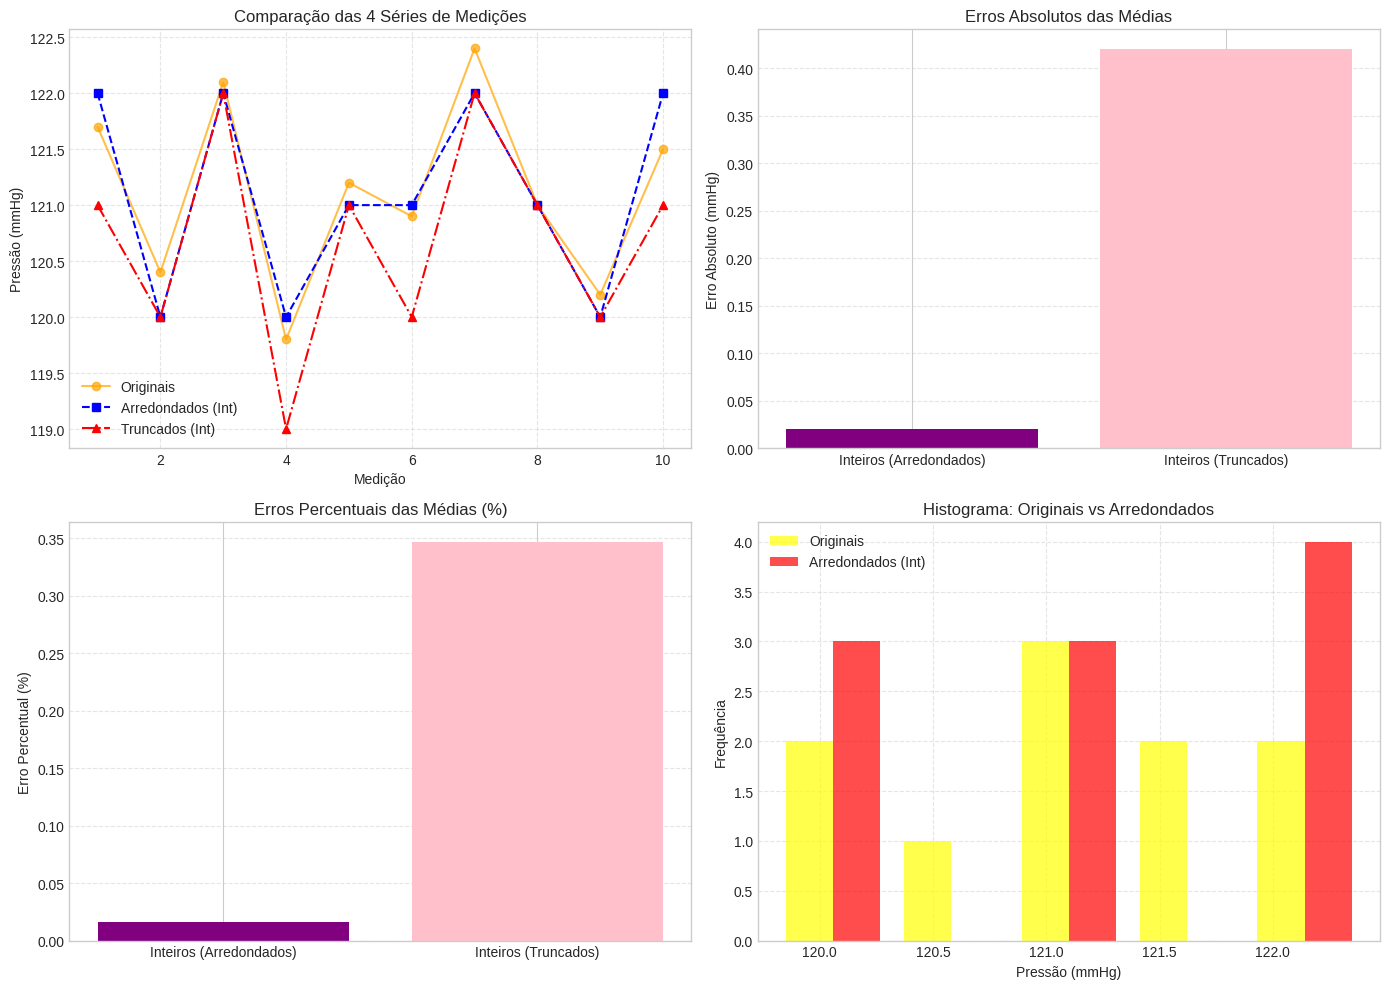

In [10]:
data_orig = np.array(
[121.7, 120.4, 122.1, 119.8, 121.2, 120.9, 122.4, 121.0, 120.2, 121.5]
)

# Criação das quatro séries
data_round_int = np.round(data_orig).astype(int) # Arredondados para inteiro
data_trunc_int = np.trunc(data_orig).astype(int) # Truncados para inteiro

series_dict = {
"Originais": data_orig,
"Inteiros (Arredondados)": data_round_int,
"Inteiros (Truncados)": data_trunc_int,
}

# Média de referência (dados originais com todos os algarismos)
ref_mean = np.mean(data_orig)

# B.1 Cálculo das estatísticas e erros
results = []
for name, arr in series_dict.items():
    mean = np.mean(arr)
    mini = np.min(arr)
    maxi = np.max(arr)
    amp = maxi - mini
    std = np.std(arr, ddof=1) # Desvio-padrão amostral

    # Três erros da média aproximada em relação à média de referência
    abs_error = np.abs(mean - ref_mean)
    rel_error = abs_error / np.abs(ref_mean)
    pct_error = rel_error * 100

    results.append({
    "Série": name,
    "Média": mean,
    "Mínimo": mini,
    "Máximo": maxi,
    "Amplitude": amp,
    "Desvio Padrão": std,
    "Erro Absoluto": abs_error,
    "Erro Relativo": rel_error,
    "Erro Percentual (%)": pct_error,
    })

df_res = pd.DataFrame(results)
print(df_res.to_string(index=False))

# B.2 Geração dos Gráficos Obrigatórios
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
x = np.arange(1, 11)

# 1. Gráfico das 10 medições mostrando as quatro séries
axes[0, 0].plot(
x, data_orig, "o-", label="Originais", color="orange", alpha=0.7
)
axes[0, 0].plot(
x, data_round_int, "s--", label="Arredondados (Int)", color="blue"
)
axes[0, 0].plot(
x, data_trunc_int, "^-.", label="Truncados (Int)", color="red"
)

axes[0, 0].set_title("Comparação das 4 Séries de Medições")
axes[0, 0].set_xlabel("Medição")
axes[0, 0].set_ylabel("Pressão (mmHg)")
axes[0, 0].legend()
axes[0, 0].grid(True, linestyle="--", alpha=0.5)

# 2. Gráfico de barras dos erros absolutos das médias (exceto a referência)
sub_df = df_res[df_res["Série"] != "Originais"]
axes[0, 1].bar(
sub_df["Série"], sub_df["Erro Absoluto"], color=["purple", "pink", "black"]
)
axes[0, 1].set_title("Erros Absolutos das Médias")
axes[0, 1].set_ylabel("Erro Absoluto (mmHg)")
axes[0, 1].grid(True, axis="y", linestyle="--", alpha=0.5)

# 3. Gráfico de barras dos erros percentuais das médias
axes[1, 0].bar(
sub_df["Série"],
sub_df["Erro Percentual (%)"],
color=["purple", "pink", "green"],
)
axes[1, 0].set_title("Erros Percentuais das Médias (%)")
axes[1, 0].set_ylabel("Erro Percentual (%)")
axes[1, 0].grid(True, axis="y", linestyle="--", alpha=0.5)

# 4. Histograma dos dados originais e dos dados inteiros arredondados
axes[1, 1].hist(
[data_orig, data_round_int],
label=["Originais", "Arredondados (Int)"],
bins=5,
alpha=0.7,
color=["yellow", "red"],
)
axes[1, 1].set_title("Histograma: Originais vs Arredondados")
axes[1, 1].set_xlabel("Pressão (mmHg)")
axes[1, 1].set_ylabel("Frequência")
axes[1, 1].legend()
axes[1, 1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

*A representação inteira não é suficiente para preservar integralmente nem a média nem a variabilidade dessa pequena amostra, provocando distorções numéricas observáveis. Ao desconsiderar as casas decimais por arredondamento ou truncamento, a média amostral sofre um deslocamento numérico em relação ao valor de referência original, introduzindo um erro absoluto sistemático. Além disso, a conversão dos dados para números inteiros altera significativamente a dispersão e os limites dos dados, modificando a amplitude total e o desvio-padrão amostral. Como a amostragem é reduzida (apenas dez medições), a perda de precisão decimal achata ou agrupa artificialmente valores distintos em um mesmo degrau inteiro, camuflando pequenas variações consecutivas e degradando a sensibilidade estatística da amostra original.*

##Parte 05.


Feito por Vinicius

=== C.1 PRECISÃO DAS VARIÁVEIS (TABELA DE ERROS DE Q) ===
                          Cenário  Vazão Q (m³/s)  Ea (m³/s)         Er      E% (%)
    1. Referência (Todos valores)      0.00000028 0.00000000 0.00000000  0.00000000
        2. r arred/trunc (0.8 mm)      0.00000028 0.00000000 0.00000000  0.00000000
    3. µ arred/trunc (0.004 Pa.s)      0.00000024 0.00000003 0.12500000 12.50000000
      4. Δp arred/trunc (1200 Pa)      0.00000028 0.00000000 0.00000000  0.00000000
5. Todas aproximações simultâneas      0.00000024 0.00000003 0.12500000 12.50000000




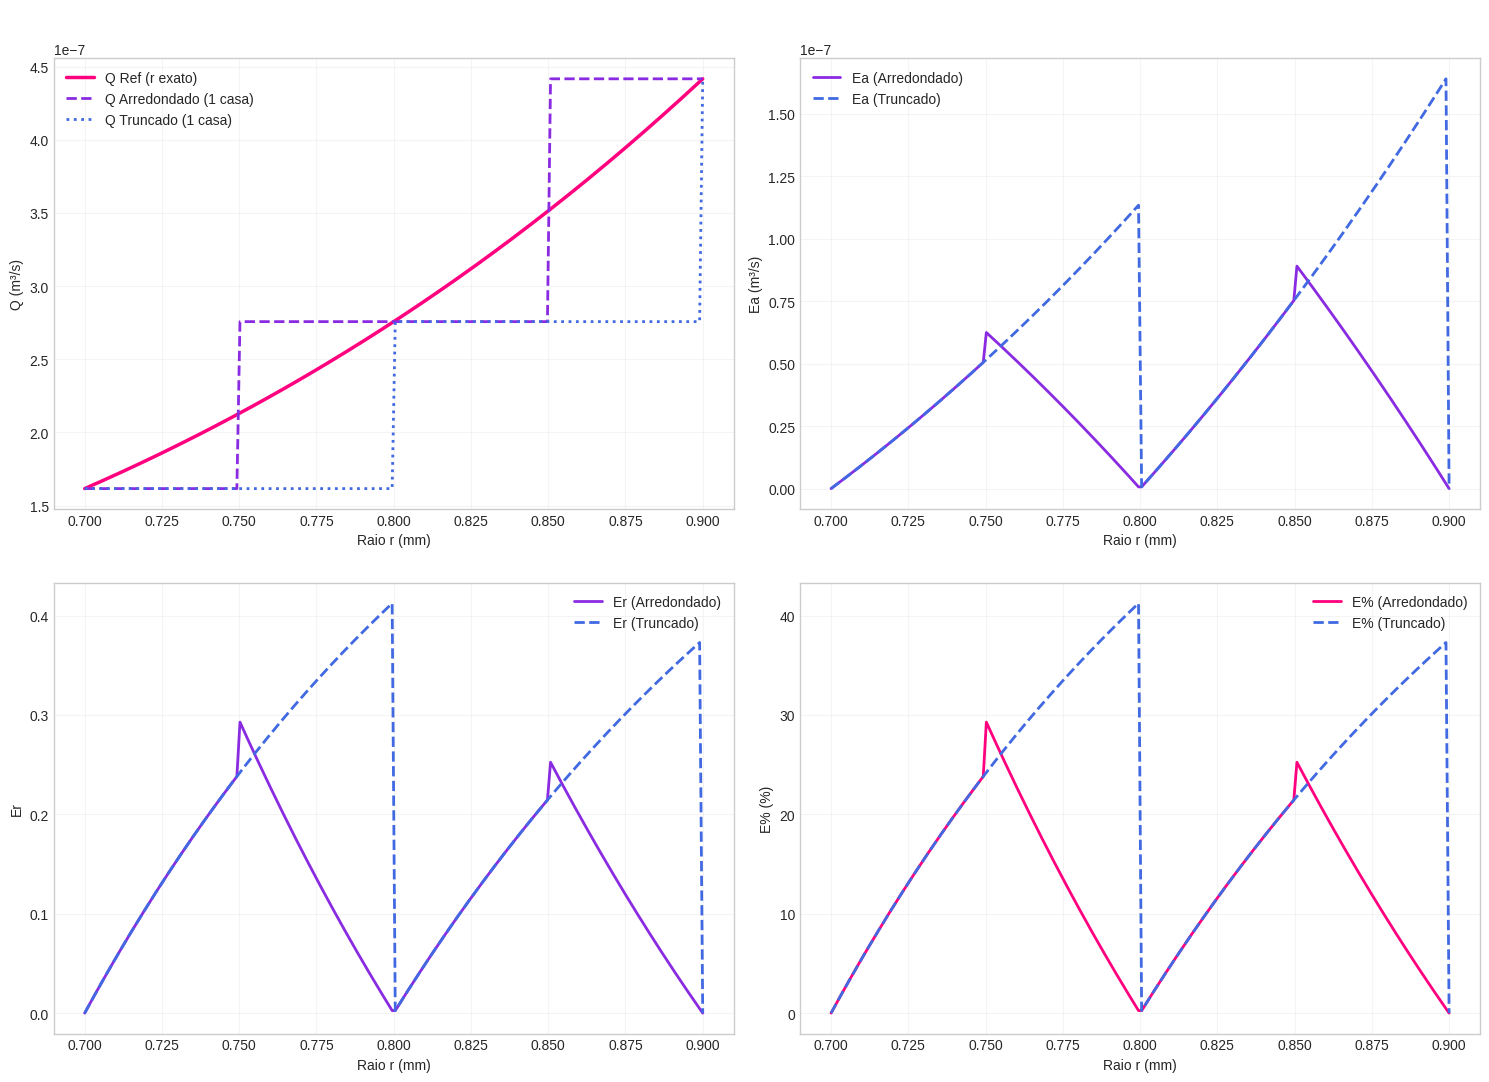

In [11]:

plt.style.use("seaborn-v0_8-whitegrid")

# ==========================================
# C.1 PRECISÃO DAS VARIÁVEIS (CÁLCULO DIRETO)
# ==========================================

# Valores de referência originais (convertidos para o SI)
r_ref = 0.80e-3      # 0.80 mm -> m
L_ref = 0.20         # 0.20 m
mu_ref = 3.5e-3      # Pa.s
dp_ref = 1200.0      # Pa

def hagen_poiseuille(r, dp, mu, L):
    """Calcula a vazão Q pela relação de Hagen-Poiseuille."""
    return (np.pi * (r**4) * dp) / (8 * mu * L)

def calc_erros(q_aprox, q_ref):
    ea = abs(q_ref - q_aprox)
    er = ea / abs(q_ref)
    ep = er * 100
    return ea, er, ep

# Q de referência exato
Q_ref = hagen_poiseuille(r_ref, dp_ref, mu_ref, L_ref)

# Validações aproximadas para cada cenário C.1
cenarios = {
    "1. Referência (Todos valores)": (r_ref, mu_ref, dp_ref),
    "2. r arred/trunc (0.8 mm)": (0.8e-3, mu_ref, dp_ref),
    "3. µ arred/trunc (0.004 Pa.s)": (r_ref, 4.0e-3, dp_ref),
    "4. Δp arred/trunc (1200 Pa)": (r_ref, mu_ref, 1200.0),
    "5. Todas aproximações simultâneas": (0.8e-3, 4.0e-3, 1200.0)
}

res_c1 = []
for nome, (r_c, mu_c, dp_c) in cenarios.items():
    Q_c = hagen_poiseuille(r_c, dp_c, mu_c, L_ref)
    ea, er, ep = calc_erros(Q_c, Q_ref)
    res_c1.append({
        "Cenário": nome,
        "Vazão Q (m³/s)": Q_c,
        "Ea (m³/s)": ea,
        "Er": er,
        "E% (%)": ep
    })

df_c1 = pd.DataFrame(res_c1)
print("=== C.1 PRECISÃO DAS VARIÁVEIS (TABELA DE ERROS DE Q) ===")
print(df_c1.to_string(index=False))
print("\n" + "="*60 + "\n")


# ==========================================
# C.2 SENSIBILIDADE E GRÁFICOS (VARIAÇÃO DO RAIO)
# ==========================================

# Raio variando de 0.70 a 0.90 mm (em mm para o eixo X do gráfico)
r_mm_vetor = np.linspace(0.70, 0.90, 200)

# Cálculos das séries de Q
Q_ref_vetor = []
Q_arred_vetor = []
Q_trunc_vetor = []

Ea_arred, Er_arred, Ep_arred = [], [], []
Ea_trunc, Er_trunc, Ep_trunc = [], [], []

def truncar_1casa(val):
    return np.trunc(val * 10) / 10

for r_mm in r_mm_vetor:
    r_m = r_mm * 1e-3
    r_arred_m = round(r_mm, 1) * 1e-3
    r_trunc_m = truncar_1casa(r_mm) * 1e-3

    # Qs
    q_r = hagen_poiseuille(r_m, dp_ref, mu_ref, L_ref)
    q_a = hagen_poiseuille(r_arred_m, dp_ref, mu_ref, L_ref)
    q_t = hagen_poiseuille(r_trunc_m, dp_ref, mu_ref, L_ref)

    Q_ref_vetor.append(q_r)
    Q_arred_vetor.append(q_a)
    Q_trunc_vetor.append(q_t)

    # Erros Arredondamento
    ea_a, er_a, ep_a = calc_erros(q_a, q_r)
    Ea_arred.append(ea_a)
    Er_arred.append(er_a)
    Ep_arred.append(ep_a)

    # Erros Truncamento
    ea_t, er_t, ep_t = calc_erros(q_t, q_r)
    Ea_trunc.append(ea_t)
    Er_trunc.append(er_t)
    Ep_trunc.append(ep_t)

# Paleta Vibrante: Rosa Choque, Roxo Violeta, Azul Royal
COLOR_REF = "#FF007F"     # Vibrant Pink / Magenta
COLOR_ARRED = "#8A2BE2"   # Blue Violet / Roxo
COLOR_TRUNC = "#4169E1"   # Royal Blue

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# 1. Q em função de r
axes[0, 0].plot(r_mm_vetor, Q_ref_vetor, label="Q Ref (r exato)", color=COLOR_REF, linewidth=2.5)
axes[0, 0].plot(r_mm_vetor, Q_arred_vetor, label="Q Arredondado (1 casa)", color=COLOR_ARRED, linestyle="--", linewidth=2)
axes[0, 0].plot(r_mm_vetor, Q_trunc_vetor, label="Q Truncado (1 casa)", color=COLOR_TRUNC, linestyle=":", linewidth=2)
axes[0, 0].set_title("1. Vazão (Q) em função do Raio (r)", fontweight="bold", color="white")
axes[0, 0].set_xlabel("Raio r (mm)")
axes[0, 0].set_ylabel("Q (m³/s)")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.2)

# 2. Erro Absoluto de Q em função de r
axes[0, 1].plot(r_mm_vetor, Ea_arred, label="Ea (Arredondado)", color=COLOR_ARRED, linewidth=2)
axes[0, 1].plot(r_mm_vetor, Ea_trunc, label="Ea (Truncado)", color=COLOR_TRUNC, linewidth=2, linestyle="--")
axes[0, 1].set_title("2. Erro Absoluto (Ea) de Q em função de r", fontweight="bold", color="white")
axes[0, 1].set_xlabel("Raio r (mm)")
axes[0, 1].set_ylabel("Ea (m³/s)")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.2)

# 3. Erro Relativo de Q em função de r
axes[1, 0].plot(r_mm_vetor, Er_arred, label="Er (Arredondado)", color=COLOR_ARRED, linewidth=2)
axes[1, 0].plot(r_mm_vetor, Er_trunc, label="Er (Truncado)", color=COLOR_TRUNC, linewidth=2, linestyle="--")
axes[1, 0].set_title("3. Erro Relativo (Er) de Q em função de r", fontweight="bold", color="white")
axes[1, 0].set_xlabel("Raio r (mm)")
axes[1, 0].set_ylabel("Er")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.2)

# 4. Erro Percentual de Q em função de r
axes[1, 1].plot(r_mm_vetor, Ep_arred, label="E% (Arredondado)", color=COLOR_REF, linewidth=2)
axes[1, 1].plot(r_mm_vetor, Ep_trunc, label="E% (Truncado)", color=COLOR_TRUNC, linewidth=2, linestyle="--")
axes[1, 1].set_title("4. Erro Percentual (E%) de Q em função de r", fontweight="bold", color="white")
axes[1, 1].set_xlabel("Raio r (mm)")
axes[1, 1].set_ylabel("E% (%)")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.2)

plt.suptitle("PARTE C – Análise de Sensibilidade da Vazão (Hagen-Poiseuille)", fontsize=16, fontweight="bold", color="white")
plt.tight_layout()
plt.show()

*O expoente 4 atua como um fator multiplicador direto da incerteza. Isso significa que qualquer erro percentual cometido na medição ou aproximação do raio é amplificado em aproximadamente quatro vezes na vazão final. Por exemplo, um pequeno erro de 2% ao arredondar ou truncar o raio resulta em um erro de cerca de 8% no cálculo da vazão do fluido.*

##Parte 06.

Feito por Vinicius

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Paleta Vibrante de Alto Contraste (Fundo Claro)
COLOR_REF = "#FF007F"  # Rosa Choque / Magenta
COLOR_PLUS = "#8A2BE2"  # Roxo Violeta
COLOR_MINUS = "#4169E1"  # Azul Royal

# Aproximação linear para Erro Percentual: 4 * (Δr / r) * 100
aprox_linear_Ep = 4 * (delta_r / r_base) * 100

fig, axes = plt.subplots(2, 2, figsize=(15, 11), facecolor="white")

for ax in axes.flat:
    ax.set_facecolor("#FAFAFA")
    ax.grid(True, linestyle=":", alpha=0.6, color="#CCCCCC")

# 1. Gráfico de Q(r-), Q(r) e Q(r+)
axes[0, 0].plot(
    delta_r_nm, Q_mais, label="Q(r+ Δr)", color=COLOR_PLUS, linewidth=2.2
)
axes[0, 0].axhline(
    Q_ref,
    color=COLOR_REF,
    linestyle="--",
    linewidth=2,
    label=f"Q(r) nominal ({r_base*1e9:.0f} nm)",
)
axes[0, 0].plot(
    delta_r_nm, Q_menos, label="Q(r- Δr)", color=COLOR_MINUS, linewidth=2.2
)
axes[0, 0].set_title(
    "1. Vazões Q(r-), Q(r) e Q(r+)", fontweight="bold", color="#111111"
)
axes[0, 0].set_xlabel("Variação no raio Δr (nm)", color="#111111")
axes[0, 0].set_ylabel("Q (m³/s)", color="#111111")
axes[0, 0].legend()

# 2. Gráfico do Erro Absoluto Máximo de Q
axes[0, 1].plot(delta_r_nm, Ea_max, color=COLOR_PLUS, linewidth=2.5)
axes[0, 1].set_title(
    "2. Erro Absoluto Máximo de Q", fontweight="bold", color="#111111"
)
axes[0, 1].set_xlabel("Variação no raio Δr (nm)", color="#111111")
axes[0, 1].set_ylabel("Ea Máximo (m³/s)", color="#111111")

# 3. Gráfico do Erro Relativo Máximo vs Aproximação Linear
axes[1, 0].plot(
    delta_r_nm,
    Er_max,
    label="Er Máximo Calculado",
    color=COLOR_PLUS,
    linewidth=2.5,
)
axes[1, 0].plot(
    delta_r_nm,
    aprox_linear_Er,
    label="Aproximação Linear 4*(Δr/r)",
    color=COLOR_REF,
    linestyle="--",
    linewidth=2,
)
axes[1, 0].set_title(
    "3. Erro Relativo Máximo de Q", fontweight="bold", color="#111111"
)
axes[1, 0].set_xlabel("Variação no raio Δr (nm)", color="#111111")
axes[1, 0].set_ylabel("Er", color="#111111")
axes[1, 0].legend()

# 4. Gráfico 4 REFEITO: Erro Percentual Máximo vs Aproximação Linear
axes[1, 1].plot(
    delta_r_nm,
    Ep_max,
    label="E% Máximo Calculado (Direto)",
    color=COLOR_PLUS,
    linewidth=2.5,
)
axes[1, 1].plot(
    delta_r_nm,
    aprox_linear_Ep,
    label="Aproximação Linear 4*(Δr/r)*100",
    color=COLOR_REF,
    linestyle="--",
    linewidth=2,
)
axes[1, 1].set_title(
    "4. Erro Percentual Máximo (Direto vs Linear)",
    fontweight="bold",
    color="#111111",
)
axes[1, 1].set_xlabel("Variação no raio Δr (nm)", color="#111111")
axes[1, 1].set_ylabel("E% (%)", color="#111111")
axes[1, 1].legend()

plt.suptitle(
    "PARTE D – Escoamento em Nanocateter: Sensibilidade Geométrica e Precisão",
    fontsize=16,
    fontweight="bold",
    color="#111111",
)
plt.tight_layout()
plt.show()

NameError: name 'delta_r' is not defined

*Ao comparar as expressões $\delta_1 = \frac{Q(r + \Delta r) - Q(r)}{Q(r)}$ e $\delta_2 = \left(1 + \frac{\Delta r}{r}\right)^4 - 1$ para valores progressivamente menores de $\frac{\Delta r}{r}$, evidencia-se a ocorrência do cancelamento catastrófico na primeira fórmula. Ao realizar a subtração $Q(r + \Delta r) - Q(r)$ com variações infinitesimalmente pequenas, opera-se com dois valores praticamente idênticos na memória computacional, o que descarta os dígitos mais significativos à esquerda e amplifica o ruído de arredondamento nos bits finais. Por outro lado, a expressão $\delta_2$ contorna a perda massiva de precisão ao isolar a razão adimensional $\frac{\Delta r}{r}$, eliminando a escala das grandezas fluídicas elevadas a ordens de magnitude extremas e mantendo a estabilidade numérica onde a fórmula direta perde significância e diverge.*

##Parte 07.

Feito por Mariana e Vinicius

/tmp/ipykernel_3465/1114887806.py:222: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Liberation Sans.
  plt.savefig(
/tmp/ipykernel_3465/1114887806.py:222: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Liberation Sans.
  plt.savefig(
/tmp/ipykernel_3465/1114887806.py:222: UserWarning: Glyph 8308 (\N{SUPERSCRIPT FOUR}) missing from font(s) Liberation Sans.
  plt.savefig(
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8308 (\N{SUPERSCRIPT FOUR}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(by

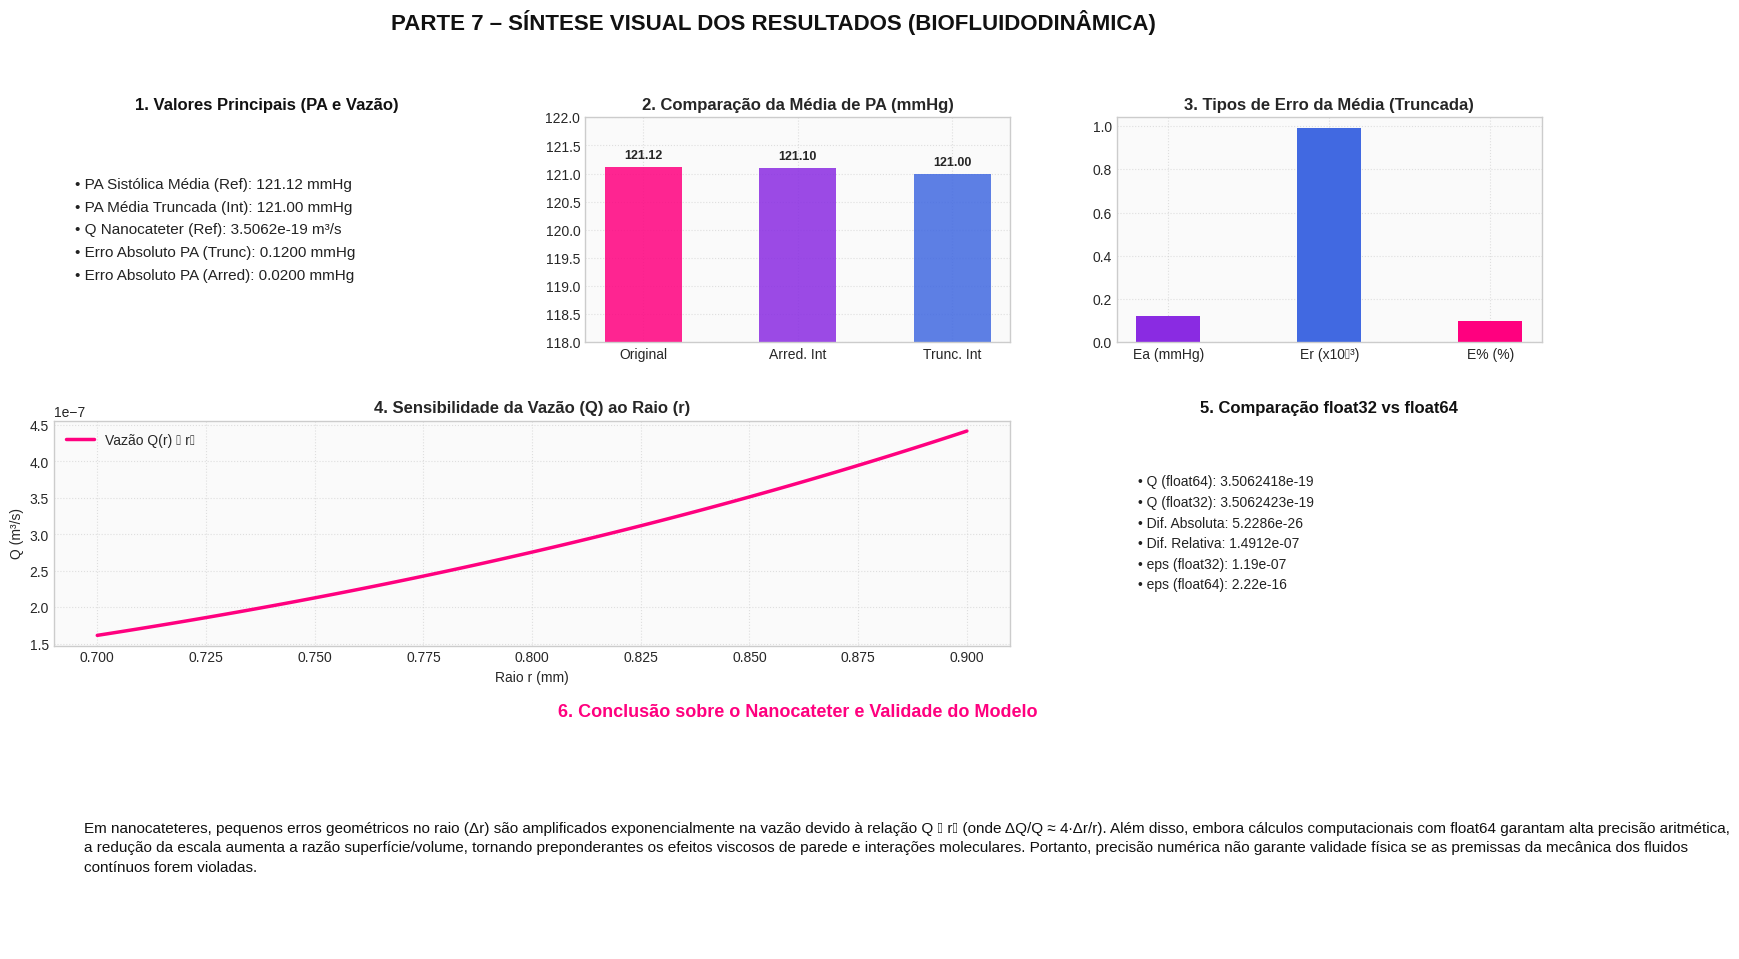

Quadro: 'quadro_sintese_resultados.png'


In [14]:
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt

# ==========================================
# 1. PREPARAÇÃO DOS DADOS SIMULADOS DA SÍNTESE
# ==========================================

# Dados Parte B (Pressão Arterial)
pa_orig = np.array(
    [121.7, 120.4, 122.1, 119.8, 121.2, 120.9, 122.4, 121.0, 120.2, 121.5]
)
pa_arred_int = np.round(pa_orig)
pa_trunc_int = np.trunc(pa_orig)
pa_arred_1dec = np.round(pa_orig, 1)

med_ref_pa = np.mean(pa_orig)
med_arred_int = np.mean(pa_arred_int)
med_trunc_int = np.trunc(med_ref_pa)  # aproximado
med_arred_1dec = np.mean(pa_arred_1dec)

ea_pa_arred = abs(med_ref_pa - med_arred_int)
ea_pa_trunc = abs(med_ref_pa - med_trunc_int)

# Dados Parte C (Sensibilidade Q x r)
r_mm = np.linspace(0.70, 0.90, 100)
r_m = r_mm * 1e-3
L, mu, dp = 0.20, 3.5e-3, 1200.0
Q_c = (np.pi * (r_m**4) * dp) / (8 * mu * L)

# Erros float32 vs float64 (Parte D)
r_nano = 50e-9
L_nano, mu_nano, dp_nano = 10e-6, 3.5e-3, 5000.0

Q_f64 = (np.pi * (np.float64(r_nano) ** 4) * dp_nano) / (8 * mu_nano * L_nano)
Q_f32 = (np.pi * (np.float32(r_nano) ** 4) * dp_nano) / (8 * mu_nano * L_nano)
diff_abs_float = abs(Q_f64 - Q_f32)
diff_rel_float = diff_abs_float / Q_f64

# ==========================================
# 2. CONSTRUÇÃO DO QUADRO ÚNICO (DASHBOARD PNG)
# ==========================================

# Resolução: 1920x1080 pixels (DPI 100 -> 19.2 x 10.8 polegadas)
fig = plt.figure(figsize=(19.2, 10.8), dpi=100, facecolor="white")
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.35, wspace=0.25)

COLOR_PINK = "#FF007F"  # Rosa Choque
COLOR_PURPLE = "#8A2BE2"  # Roxo
COLOR_ROYAL = "#4169E1"  # Azul Royal
COLOR_BG_CARD = "#F8F9FA"  # Cinza bem claro para os cards

# ------------------------------------------
# CARD 1: CARTÕES COM VALORES PRINCIPAIS (Linha 0, Coluna 0)
# ------------------------------------------
ax_card = fig.add_subplot(gs[0, 0])
ax_card.set_facecolor(COLOR_BG_CARD)
ax_card.axis("off")
ax_card.set_title(
    "1. Valores Principais (PA e Vazão)",
    fontweight="bold",
    fontsize=12,
    color="#111",
)

info_text = (
    f"• PA Sistólica Média (Ref): {med_ref_pa:.2f} mmHg\n"
    f"• PA Média Truncada (Int): {med_trunc_int:.2f} mmHg\n"
    f"• Q Nanocateter (Ref): {Q_f64:.4e} m³/s\n"
    f"• Erro Absoluto PA (Trunc): {ea_pa_trunc:.4f} mmHg\n"
    f"• Erro Absoluto PA (Arred): {ea_pa_arred:.4f} mmHg"
)
ax_card.text(
    0.05,
    0.5,
    info_text,
    fontsize=11,
    verticalalignment="center",
    color="#222",
    linespacing=1.8,
)

# ------------------------------------------
# PAINEL 2: COMPARAÇÃO TRUNCAMENTO VS ARREDONDAMENTO (Linha 0, Coluna 1)
# ------------------------------------------
ax_pa = fig.add_subplot(gs[0, 1])
ax_pa.set_facecolor("#FAFAFA")
categories = ["Original", "Arred. Int", "Trunc. Int"]
means = [med_ref_pa, med_arred_int, med_trunc_int]
bars = ax_pa.bar(
    categories,
    means,
    color=[COLOR_PINK, COLOR_PURPLE, COLOR_ROYAL],
    alpha=0.85,
    width=0.5,
)
ax_pa.set_ylim(118, 122)
ax_pa.set_title(
    "2. Comparação da Média de PA (mmHg)", fontweight="bold", fontsize=12
)
ax_pa.grid(True, linestyle=":", alpha=0.6)
for bar in bars:
    yval = bar.get_height()
    ax_pa.text(
        bar.get_x() + bar.get_width() / 2,
        yval + 0.1,
        f"{yval:.2f}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
    )

# ------------------------------------------
# PAINEL 3: OS TRÊS TIPOS DE ERRO (Linha 0, Coluna 2)
# ------------------------------------------
ax_erros = fig.add_subplot(gs[0, 2])
ax_erros.set_facecolor("#FAFAFA")
tipos_erro = ["Ea (mmHg)", "Er (x10⁻³)", "E% (%)"]
valores_erros = [
    ea_pa_trunc,
    (ea_pa_trunc / med_ref_pa) * 1000,
    (ea_pa_trunc / med_ref_pa) * 100,
]
ax_erros.bar(
    tipos_erro,
    valores_erros,
    color=[COLOR_PURPLE, COLOR_ROYAL, COLOR_PINK],
    width=0.4,
)
ax_erros.set_title(
    "3. Tipos de Erro da Média (Truncada)", fontweight="bold", fontsize=12
)
ax_erros.grid(True, linestyle=":", alpha=0.6)

# ------------------------------------------
# PAINEL 4: SENSIBILIDADE DE Q AO RAIO (Linha 1, Coluna 0:2) - Ocupa 2 colunas
# ------------------------------------------
ax_sens = fig.add_subplot(gs[1, 0:2])
ax_sens.set_facecolor("#FAFAFA")
ax_sens.plot(
    r_mm, Q_c, color=COLOR_PINK, linewidth=2.5, label="Vazão Q(r) ∝ r⁴"
)
ax_sens.set_title(
    "4. Sensibilidade da Vazão (Q) ao Raio (r)", fontweight="bold", fontsize=12
)
ax_sens.set_xlabel("Raio r (mm)")
ax_sens.set_ylabel("Q (m³/s)")
ax_sens.grid(True, linestyle=":", alpha=0.6)
ax_sens.legend(loc="upper left")

# ------------------------------------------
# PAINEL 5: COMPARAÇÃO FLOAT32 E FLOAT64 (Linha 1, Coluna 2)
# ------------------------------------------
ax_float = fig.add_subplot(gs[1, 2])
ax_float.set_facecolor(COLOR_BG_CARD)
ax_float.axis("off")
ax_float.set_title(
    "5. Comparação float32 vs float64",
    fontweight="bold",
    fontsize=12,
    color="#111",
)

text_float = (
    f"• Q (float64): {Q_f64:.7e}\n"
    f"• Q (float32): {Q_f32:.7e}\n"
    f"• Dif. Absoluta: {diff_abs_float:.4e}\n"
    f"• Dif. Relativa: {diff_rel_float:.4e}\n"
    f"• eps (float32): {np.finfo(np.float32).eps:.2e}\n"
    f"• eps (float64): {np.finfo(np.float64).eps:.2e}"
)
ax_float.text(
    0.05,
    0.5,
    text_float,
    fontsize=10,
    verticalalignment="center",
    color="#222",
    linespacing=1.6,
)

# ------------------------------------------
# PAINEL 6: CONCLUSÃO CURTA SOBRE O NANOCATETER (Linha 2, Coluna 0:3) - Ocupa linha inteira
# ------------------------------------------
ax_conc = fig.add_subplot(gs[2, :])
ax_conc.set_facecolor("#FFF0F5")  # Fundo levemente rosado para destaque
ax_conc.axis("off")
ax_conc.set_title(
    "6. Conclusão sobre o Nanocateter e Validade do Modelo",
    fontweight="bold",
    fontsize=13,
    color=COLOR_PINK,
)

texto_conclusao = (
    "Em nanocateteres, pequenos erros geométricos no raio (Δr) são amplificados exponencialmente na vazão devido à relação Q ∝ r⁴ "
    "(onde ΔQ/Q ≈ 4·Δr/r). Além disso, embora cálculos computacionais com float64 garantam alta precisão aritmética, a redução da escala "
    "aumenta a razão superfície/volume, tornando preponderantes os efeitos viscosos de parede e interações moleculares. "
    "Portanto, precisão numérica não garante validade física se as premissas da mecânica dos fluidos contínuos forem violadas."
)
ax_conc.text(
    0.02,
    0.45,
    texto_conclusao,
    fontsize=11,
    verticalalignment="center",
    color="#111",
    wrap=True,
    linespacing=1.5,
)

# Título Principal do Quadro
plt.suptitle(
    "PARTE 7 – SÍNTESE VISUAL DOS RESULTADOS (BIOFLUIDODINÂMICA)",
    fontsize=16,
    fontweight="bold",
    color="#111",
    y=0.98,
)

# Salvando em PNG com resolução mínima de 1920x1080
plt.savefig(
    "quadro_sintese_resultados.png",
    dpi=100,
    bbox_inches="tight",
    facecolor="white",
)
plt.show()

print("Quadro: 'quadro_sintese_resultados.png'")

##Parte 08.

Feito por Mariana e Vinicius

GIF: 'nanocateter_escoamento.gif' (45 quadros)


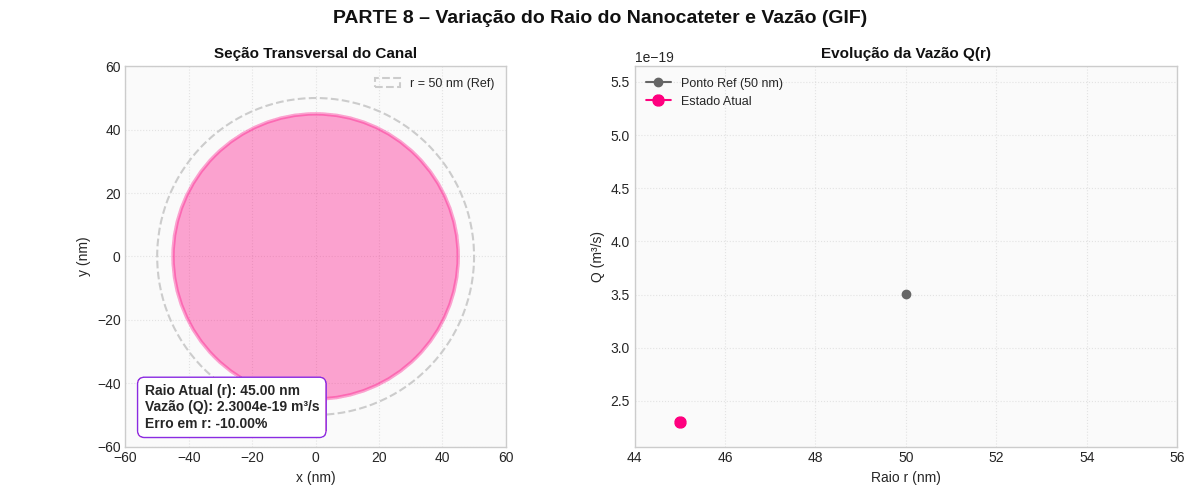

In [16]:
import os
import matplotlib.animation as animation
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. PARÂMETROS FÍSICOS DO NANOCATETER
# ==========================================
L_nano = 10e-6  # 10 µm
mu_nano = 3.5e-3  # 3.5 x 10^-3 Pa.s
dp_nano = 5000.0  # 5000 Pa

r_ref_nm = 50.0  # Raio de referência (50 nm)
r_ref_m = r_ref_nm * 1e-9


def hagen_poiseuille(r_m):
    return (np.pi * (r_m**4) * dp_nano) / (8 * mu_nano * L_nano)


# Vazão nominal a r = 50 nm
Q_ref = hagen_poiseuille(r_ref_m)

# Raio variando de 45 a 55 nm (45 quadros)
num_frames = 45
r_vetor_nm = np.linspace(45.0, 55.0, num_frames)
r_vetor_m = r_vetor_nm * 1e-9
Q_vetor = hagen_poiseuille(r_vetor_m)

# Cores Vibrantes (Fundo Claro)
COLOR_PINK = "#FF007F"  # Rosa Choque
COLOR_PURPLE = "#8A2BE2"  # Roxo
COLOR_ROYAL = "#4169E1"  # Azul Royal

# ==========================================
# 2. CONFIGURAÇÃO DA FIGURA DA ANIMAÇÃO
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), facecolor="white")
fig.suptitle(
    "PARTE 8 – Variação do Raio do Nanocateter e Vazão (GIF)",
    fontsize=14,
    fontweight="bold",
    color="#111",
)

# Painel 1: Seção Transversal do Nanocateter
ax1.set_facecolor("#FAFAFA")
ax1.set_xlim(-60, 60)
ax1.set_ylim(-60, 60)
ax1.set_aspect("equal")
ax1.set_title(
    "Seção Transversal do Canal", fontweight="bold", fontsize=11, color="#111"
)
ax1.set_xlabel("x (nm)")
ax1.set_ylabel("y (nm)")
ax1.grid(True, linestyle=":", alpha=0.5)

# Círculo fixo de referência (r = 50 nm)
circle_ref = plt.Circle(
    (0, 0),
    50,
    color="#CCCCCC",
    fill=False,
    linestyle="--",
    linewidth=1.5,
    label="r = 50 nm (Ref)",
)
ax1.add_patch(circle_ref)

# Círculo dinâmico (raio atual)
circle_curr = plt.Circle(
    (0, 0), 45, color=COLOR_PINK, alpha=0.35, ec=COLOR_PINK, lw=2.5
)
ax1.add_patch(circle_curr)
ax1.legend(loc="upper right", fontsize=9)

# Texto de métricas no Painel 1
text_info = ax1.text(
    0.05,
    0.05,
    "",
    transform=ax1.transAxes,
    fontsize=10,
    fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor=COLOR_PURPLE),
)

# Painel 2: Curva Q x r Construída Progressivamente
ax2.set_facecolor("#FAFAFA")
ax2.set_xlim(44, 56)
ax2.set_ylim(min(Q_vetor) * 0.9, max(Q_vetor) * 1.1)
ax2.set_title(
    "Evolução da Vazão Q(r)", fontweight="bold", fontsize=11, color="#111"
)
ax2.set_xlabel("Raio r (nm)")
ax2.set_ylabel("Q (m³/s)")
ax2.grid(True, linestyle=":", alpha=0.5)

# Ponto nominal fixo no gráfico
ax2.plot(
    r_ref_nm,
    Q_ref,
    marker="o",
    color="#666666",
    markersize=6,
    label="Ponto Ref (50 nm)",
)

# Linha e Ponto dinâmicos
(line_progress,) = ax2.plot([], [], color=COLOR_PURPLE, linewidth=2.5)
(point_curr,) = ax2.plot(
    [], [], marker="o", color=COLOR_PINK, markersize=8, label="Estado Atual"
)
ax2.legend(loc="upper left", fontsize=9)


# ==========================================
# 3. FUNÇÕES DE ANIMAÇÃO
# ==========================================
def init():
    circle_curr.set_radius(45)
    text_info.set_text("")
    line_progress.set_data([], [])
    point_curr.set_data([], [])
    return circle_curr, text_info, line_progress, point_curr


def update(frame):
    r_curr_nm = r_vetor_nm[frame]
    r_curr_m = r_vetor_m[frame]
    Q_curr = Q_vetor[frame]

    # Erro percentual em relação a r = 50 nm
    erro_pct = ((r_curr_nm - r_ref_nm) / r_ref_nm) * 100

    # Atualiza o círculo
    circle_curr.set_radius(r_curr_nm)

    # Atualiza o texto
    text_info.set_text(
        f"Raio Atual (r): {r_curr_nm:.2f} nm\n"
        f"Vazão (Q): {Q_curr:.4e} m³/s\n"
        f"Erro em r: {erro_pct:+.2f}%"
    )

    # Atualiza o gráfico progressivo
    line_progress.set_data(r_vetor_nm[: frame + 1], Q_vetor[: frame + 1])
    point_curr.set_data([r_curr_nm], [Q_curr])

    return circle_curr, text_info, line_progress, point_curr


ani = animation.FuncAnimation(
    fig,
    update,
    frames=num_frames,
    init_func=init,
    blit=True,
    interval=100,  # 100ms por quadro
)

plt.tight_layout()

# Salvando a animação em GIF
gif_filename = "nanocateter_escoamento.gif"
ani.save(gif_filename, writer="pillow", fps=15)
plt.close()

print(f"GIF: '{gif_filename}' ({num_frames} quadros)")

from IPython.display import Image

Image(filename="nanocateter_escoamento.gif")

## Parte 09. Conclusão



*Esta atividade prática demonstrou como pequenos erros numéricos de arredondamento e truncamento, juntamente com limitações da precisão de ponto flutuante, podem se propagar e impactar drasticamente a modelagem de biofluidos. Por meio das análises de sensibilidade e do cálculo dos erros absoluto, relativo e percentual, evidenciou-se que equações não lineares amplificam incertezas geométricas de forma quadrática e não linear, tornando aproximações simplistas insuficientes. Conclui-se, portanto, que a escolha adequada de métodos numéricos, representações de dados e formulas computacionalmente estáveis é fundamental para evitar falhas de significância e garantir simulações numéricas robustas, precisas e fisicamente coerentes.*